In [1]:
# imports
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

In [2]:
# carregar os dados do banco de dados
ligas = pd.read_sql('SELECT * FROM ligas', 'sqlite:///taticatotal.db')
estadios = pd.read_sql('SELECT * FROM estadios', 'sqlite:///taticatotal.db')
times = pd.read_sql('SELECT * FROM times', 'sqlite:///taticatotal.db')
jogadores = pd.read_sql('SELECT * FROM jogadores', 'sqlite:///taticatotal.db')

times_completo = pd.merge(jogadores, times, left_on='time_id', right_on='id', how='left')
times_completo = pd.merge(times_completo, ligas, left_on='liga_id', right_on='id', how='left')
times_completo = times_completo.drop(columns=['id_x','id_y','id', 'time_id', 'liga_id', 'estadio_id'])
times_completo = times_completo.rename(columns={'nome_x': 'jogador', 'posicao': 'posicao', 'nome_y': 'time', 'nome': 'liga'})
times_completo.head(5)

,jogador,posicao,idade,overall,nacionalidade,time,liga
0,Lucca Jacquot,GO,24,56,Brasil,União Praça Rodrigues,Série C do Brasil
1,Ravi Lucca Rodríguez,GO,39,52,Brasil,União Praça Rodrigues,Série C do Brasil
2,Ryan Lozano,LE,30,58,Brasil,União Praça Rodrigues,Série C do Brasil
3,Marcos Vinicius Gimenez,LE,24,66,Brasil,União Praça Rodrigues,Série C do Brasil
4,Pietro Vilar,ZAG,40,58,Brasil,União Praça Rodrigues,Série C do Brasil


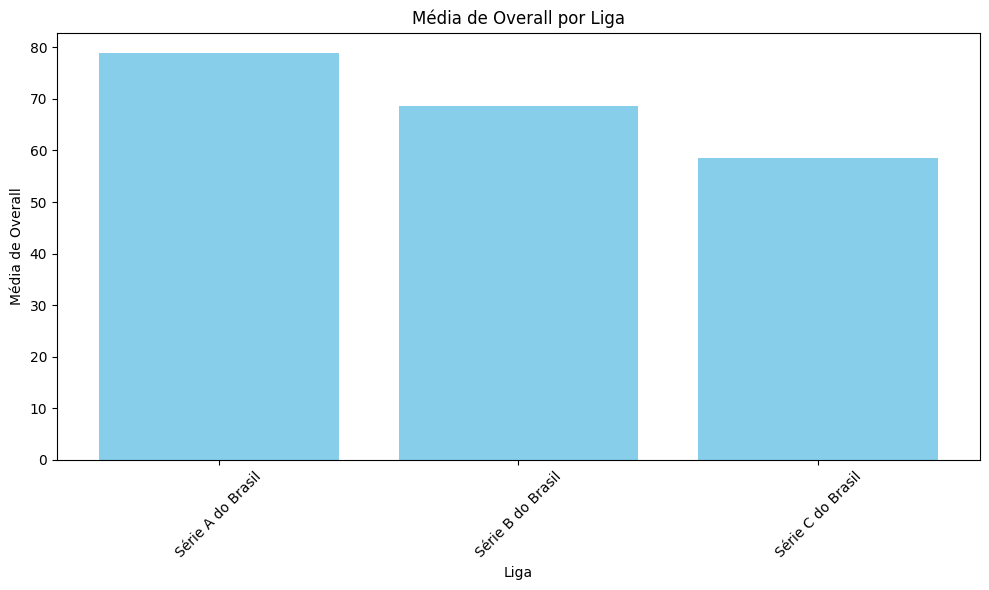

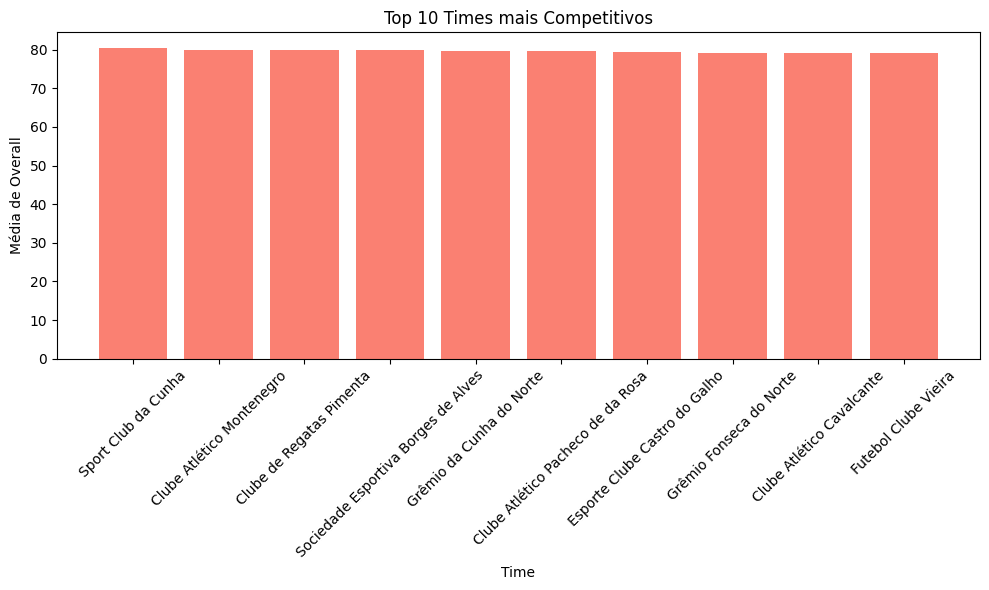

                 jogador                                   time nacionalidade  \
0           Ravy Escobar              Clube Atlético Cavalcante        Brasil   
1             Otto Arias                Grêmio Peixoto do Campo        Brasil   
2      Geronimo Gonzalez                    Sport Club da Cunha     Argentina   
3  Carlos Eduardo Terrón  Sociedade Esportiva Cassiano Paulista        Brasil   
4           Amado Téllez               Grêmio da Cunha do Norte       Bolivia   
5          Henrique Díaz      Clube Atlético Pacheco de da Rosa        Brasil   
6           David García       Clube de Regatas Pastor de Minas      Colombia   
7    João Gabriel Cuesta                Grêmio Peixoto do Campo        Brasil   
8          Pedro Jacquet    Sociedade Esportiva Borges de Alves        Brasil   
9         Lucas Barragán                Grêmio Peixoto do Campo        Brasil   

   idade posicao  overall  
0     19      ME     90.0  
1     21      LD     90.0  
2     29     VOL     90.

In [3]:
# analise de dados
# ligas mais competitivas
ligas_competitivas = times_completo.groupby('liga')['overall'].mean().reset_index().sort_values(by='overall', ascending=False)
# print(ligas_competitivas)
plt.figure(figsize=(10, 6))
plt.bar(ligas_competitivas['liga'], ligas_competitivas['overall'], color='skyblue')
plt.xlabel('Liga')
plt.ylabel('Média de Overall')
plt.title('Média de Overall por Liga')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# times mais competitivos
times_competitivos = times_completo.groupby(['time', 'liga'])['overall'].mean().reset_index().sort_values(by='overall', ascending=False)
# print(times_competitivos.head(10))
plt.figure(figsize=(10, 6))
plt.bar(times_competitivos['time'][:10], times_competitivos['overall'][:10], color='salmon')
plt.xlabel('Time')
plt.ylabel('Média de Overall')
plt.title('Top 10 Times mais Competitivos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# jogadores mais competitivos
jogadores_competitivos = times_completo.groupby(['jogador', 'time', 'nacionalidade', 'idade', 'posicao'])['overall'].mean().reset_index().sort_values(by='overall', ascending=False)
jogadores_competitivos.head(10).reset_index(drop=True)
print(jogadores_competitivos.head(10).reset_index(drop=True))

# media de overall por posição da serie a
serie_a = times_completo[times_completo['liga'] == 'Série A do Brasil']
media_overall_posicao = serie_a.groupby('posicao')['overall'].mean().sort_values(ascending=False).reset_index()
print(media_overall_posicao)


In [4]:
# media de overall por time e liga
times_final = times_completo.groupby(['time', 'liga'])['overall'].mean().reset_index().sort_values(by='overall', ascending=False).reset_index(drop=True)
times_final

,time,liga,overall
0,Sport Club da Cunha,Série A do Brasil,80.468750
1,Clube Atlético Montenegro,Série A do Brasil,79.857143
2,Clube de Regatas Pimenta,Série A do Brasil,79.806452
3,Sociedade Esportiva Borges de Alves,Série A do Brasil,79.793103
4,Grêmio da Cunha do Norte,Série A do Brasil,79.655172
5,Clube Atlético Pacheco de da Rosa,Série A do Brasil,79.642857
6,Esporte Clube Castro do Galho,Série A do Brasil,79.466667
7,Grêmio Fonseca do Norte,Série A do Brasil,79.178571
8,Clube Atlético Cavalcante,Série A do Brasil,79.031250
9,Futebol Clube Vieira,Série A do Brasil,79.031250


In [13]:
# gerar a melhor escalação do time para a melhor formação tática
def gerar_escalacao_melhor_formacao(time):
    # definir as formações táticas e as posições correspondentes
    formacoes = {
        '3-4-3': ['GO', 'ZAG', 'ZAG', 'ZAG', 'MC', 'MC', 'ME', 'MD', 'PE', 'PD', 'ATA'],
        '3-5-2': ['GO', 'ZAG', 'ZAG', 'ZAG', 'VOL', 'VOL', 'MEI', 'ME', 'MD', 'ATA', 'ATA'],
        '4-4-2': ['GO', 'ZAG', 'ZAG', 'LD', 'LE', 'MC', 'MC', 'ME', 'MD', 'ATA', 'ATA'],
        '4-3-3 EM LINHA': ['GO', 'ZAG', 'ZAG', 'LD', 'LE', 'MC', 'MC', 'MC', 'PE', 'PD', 'ATA'],
        '4-3-3 OFENSIVO': ['GO', 'ZAG', 'ZAG', 'LD', 'LE', 'MC', 'MEI', 'MC', 'PE', 'PD', 'ATA'],
        '4-3-3 DEFENSIVO': ['GO', 'ZAG', 'ZAG', 'LD', 'LE', 'VOL', 'MC', 'VOL', 'PE', 'PD', 'ATA'],
        '4-2-3-1': ['GO', 'ZAG', 'ZAG', 'LD', 'LE', 'VOL', 'VOL', 'MEI', 'ME', 'MD', 'ATA'],
        '5-3-2': ['GO', 'ZAG', 'ZAG', 'ZAG', 'LE', 'LD', 'MC', 'MC', 'MC', 'ATA', 'ATA'],
        '5-4-1': ['GO', 'ZAG', 'ZAG', 'ZAG', 'LE', 'LD', 'MC', 'MC', 'ME', 'MD', 'ATA']
    }
    # verificar se o time existe no dataset
    if time not in times_completo['time'].unique():
        print(f"Time '{time}' não encontrado.")
        return None
    else:
        # selecionar os jogadores do time
        time_jogadores = times_completo[times_completo['time'] == time]
        melhor_formacao = None
        melhor_media = 0
        melhor_escalacao = []
        overall_escalacao = []
        # para cada formação, selecionar os jogadores mais competitivos para as posições correspondentes e calcular a média de overall
        for formacao, posicoes in formacoes.items():
            jogadores_formacao = []
            media_overall = 0
            jogadores_selecionados = set()
            # selecionar o jogador mais competitivo para cada posição, garantindo que o mesmo jogador não seja selecionado para mais de uma posição
            for posicao in posicoes:
                jogador_posicao = time_jogadores[(time_jogadores['posicao'] == posicao) & (~time_jogadores['jogador'].isin(jogadores_selecionados))]
                jogador_posicao = jogador_posicao.sort_values(by='overall', ascending=False).head(1)
                # se houver um jogador disponível para a posição, adicioná-lo à escalação e atualizar a média de overall
                if not jogador_posicao.empty:
                    jogador = jogador_posicao.iloc[0]
                    jogadores_formacao.append(jogador['jogador'])
                    jogadores_selecionados.add(jogador['jogador'])
                    media_overall += jogador['overall']
                else:
                    jogadores_formacao.append('N/A')
            media_overall /= len(posicoes)
            if media_overall > melhor_media:
                melhor_media = media_overall
                melhor_formacao = formacao
                melhor_escalacao = jogadores_formacao
                overall_escalacao = [time_jogadores[time_jogadores['jogador'] == jogador]['overall'].values[0] if jogador != 'N/A' else 'N/A' for jogador in jogadores_formacao]
                overall_escalacao_media = round(sum(overall_escalacao)/len(overall_escalacao),2)
        print(f"Melhor formação para o time '{time}': {melhor_formacao}, Overall:{overall_escalacao_media}")
        print("Escalação:")
        for posicao, jogador, overall in zip(formacoes[melhor_formacao], melhor_escalacao, overall_escalacao):
            print(f"{posicao}: {jogador} (Overall: {overall})")
        return melhor_formacao, melhor_escalacao, overall_escalacao_media

x1, y1, z1  = gerar_escalacao_melhor_formacao('Sport Club da Cunha')
x2, y2, z2  = gerar_escalacao_melhor_formacao('Clube Atlético Montenegro')
print(f"Média de Overall da melhor escalação: {z1}")
print(f"Média de Overall da melhor escalação: {z2}")

Melhor formação para o time 'Sport Club da Cunha': 4-3-3 DEFENSIVO, Overall:84.09
Escalação:
GO: José Lazo (Overall: 82)
ZAG: Rafael Gómez (Overall: 87)
ZAG: Rodrigo Bähr (Overall: 85)
LD: João Pedro Ordóñez (Overall: 84)
LE: Rodrigo Mckenzie (Overall: 87)
VOL: Geronimo Gonzalez (Overall: 90)
MC: João Pedro Camargo (Overall: 86)
VOL: Yuri Cardano (Overall: 77)
PE: João Almeida (Overall: 86)
PD: Onofre Torrecilla (Overall: 80)
ATA: Gustavo Henrique Carpentier (Overall: 81)
Melhor formação para o time 'Clube Atlético Montenegro': 4-3-3 DEFENSIVO, Overall:82.36
Escalação:
GO: Baltasar Piña (Overall: 84)
ZAG: Eduardo Franch (Overall: 80)
ZAG: Arthur Hernandez (Overall: 78)
LD: Antony Egea (Overall: 86)
LE: Fernando Gonçalves (Overall: 78)
VOL: João Vitor Ardila (Overall: 81)
MC: Vinicius Walter (Overall: 87)
VOL: Lucca Fonseca (Overall: 79)
PE: Benjamin Perez (Overall: 87)
PD: Thiago Lenoir (Overall: 80)
ATA: Thiago Benjamin Benitez (Overall: 86)
Média de Overall da melhor escalação: 84.09